<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Python_chapter3_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 相関・回帰分析

[この章の目的]
初歩的な相関分析と回帰分析がPythonで出来るようになる。

資料: 授業のスライド (C-Learning上で公開予定)

補足資料:講義ノート
https://drive.google.com/file/d/1ZKi8DJFSg00xir1IoEQiw3z9vxmejeCv/view


## 相関分析

1年生前期の必修科目[DS入門]では多くの学科で[相関分析]を学習しました。  
「エクセルでの相関分析をやってない」という方は、必要に応じてDS入門の資料を公開しますのでお知らせください。

解析データが２種類のデータだけなら、プログラムを使うありがたみはそれほど感じられないと思いますが「多くのデータ間の相関関係を系統的に調べたい」あるいは「複数年度に渡るデータを解析したい」となると、Excelはデータが大きくなるとすぐに挙動が重くなってしまうため精神によくありません(私見)ので、Pythonで扱うのがオススメです。

以下では、簡単な例の相関分析を扱って、時間に余裕があれば、やや発展的な内容としてxlsx(csv)形式のファイルに格納された大量のデータを扱ってみることにします。

まずは簡単な例から初めましょう。


In [1]:
x= [3.1, 4.3, 6.6, 13.2, 19.1, 20.9, 26.4, 25.1, 21.9, 15.7, 9.6, 3.8]
y= [568, 572, 804, 833, 930, 965, 1213, 1120, 835, 540, 451, 502]

上に示したのは、2017年の宇都宮市における月別の平均気温と、世帯ごとのアイスクリーム・シャーベットの平均消費金額です。  
散布図にすると↓こんな感じ

     |████████████████████████████████| 4.1MB 2.8MB/s 
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.2-cp36-none-any.whl size=4120191 sha256=1c10f730167c7a7776f2e14905f677cf18a51b3a386d40500f912075f798f8a6
  Stored in directory: /root/.cache/pip/wheels/9c/f9/fc/bc052ce743a03f94ccc7fda73d1d389ce98216c6ffaaf65afc
Successfully built japanize-matplotlib


/usr/local/lib/python3.6/dist-packages/japanize_matplotlib/japanize_matplotlib.py:15: MatplotlibDeprecationWarning: 
The createFontList function was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use FontManager.addfont instead.
  font_list = font_manager.createFontList(font_files)


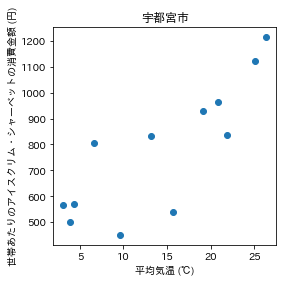

In [2]:
from matplotlib import pyplot as plt 
!pip install japanize-matplotlib 
import japanize_matplotlib 
import numpy as np 
plt.figure(figsize=(4,4)) 
plt.title("宇都宮市") ## 図にはタイトルをつけることができます
plt.xlabel("平均気温 (℃)")
plt.ylabel("世帯あたりのアイスクリム・シャーベットの消費金額 (円)")
plt.scatter(x,y)
plt.show()
plt.close()

「なんとなく平均気温とアイスの消費には相関がありそうだ」という直感の通り、正の相関があることが見て取れます。

では"どれほどの"相関を持つかを表す量として相関係数を算出してみましょう。
相関係数$r$は以下のように定義されます。
$r= \frac{ \sum^n_i (x_i-\bar{x})(y_i-\bar{y})}{ \sqrt{\sum^n_i (x_i-\bar{x})^2 \sum^n_i (y_i-\bar{y})^2} }$  
$\bar{x},\bar{y}$はそれぞれ$x,y$の平均値で、数式で書くと  
$\bar{x} \equiv \frac{1}{n} \sum^n_i x_i $  
$\bar{y} \equiv \frac{1}{n} \sum^n_i y_i $  
という感じです。ここで$\equiv$は[定義]を表し、下付き添字$i$は$x$の$i$番目の要素であることを表します。(つまり$x$をn次元ベクトルとみなしたときの$i$成分が$x_i$とも言えますね)

すなわち、今考えているデータの場合、$\sum$の和記号は$i$は1から12までの値をとり、足し上げることを意味します。("$i$の和が1から12までを走る"といったりもします)

$r$は-1から1までの値を取ることが出来ます。

では、x,y２つのリストを引数に持ち、この相関係数$r$を返す関数を作成してみましょう。

In [5]:
### ライブラリを一切使わない方法
def cor_coeff(x,y):
    if len(x) != len(y):
        print("x and y must be the same size!!") #xとyの長さが違う場合はエラーとし、返り値Noneを返す。
        return None
    n = len(x)
    xbar = sum(x)/n; ybar = sum(y)/n
    s_n = 0.0 ##分子(numerator)の和を計算 (初期値を0に)
    for i in range(n):
        s_n += (x[i]-xbar)*(y[i]-ybar)
    ##分母(denominator)の計算 (和を先に計算して積を取り、最後にsquare rootをとる)
    s_d = ( sum([(x[i]-xbar)**2   for i in range(n)]) * sum([(y[i]-ybar)**2   for i in range(n)]) )**0.5
    return s_n/s_d

cor_coeff(x,y)

0.8262304630498378

という風に$r$がだいたい0.83で、非常に強い正の相関を示すことがわかりました。

numpyライブラリを使うともう少しシンプルに書けるので、それもやっておきましょう

In [11]:
import numpy as np #他でnumpyを使わないなら関数の中にいれてもOK
def cor_coeff_np(x,y):
    x = np.array(x); y = np.array(y) ## ほんとは不要だけど一応numpy arrayにしておく...
    xbar = np.mean(x); ybar=np.mean(y) #np.mean()は整数・実数値が入ったリスト(やnumpy array)の平均を計算
    return np.dot(x - xbar,y-ybar) / np.sqrt( np.dot(x-xbar,x-xbar) * np.dot(y-ybar,y-ybar) ) ## 備考: np.sqrt()は()**0.5と等価

cor_coeff_np(x,y)

0.8262304630498378

とすると、関数自体は数行で書けてしまいました。

上のコードを少し補足しておくと...分子や分母に現れる
$\sum^n_i (x_i-\bar{x})(y_i-\bar{y})$や$\sum^n_i (x_i-\bar{x})^2 $といった和は、
$i$番目の成分に$x_i-\bar{x}$を持つベクトル$\tilde{x}$と、
$i$番目の成分に$y_i-\bar{y}$を持つベクトル$\tilde{y}$を定義しておくと、
$\tilde{x}\cdot\tilde{y}$, $\tilde{x}\cdot\tilde{x}$, $\tilde{y}\cdot\tilde{y}$といった、ベクトルの内積の形で表すことができます。

numpyにはベクトル積を計算する関数dotが定義されているのでそれを使うことで関数を短くすることができました。

実はnumpyには相関関数を計算する関数が予め用意されていて


In [14]:
print(np.corrcoef(x,y))
print("r(x,y)=", np.corrcoef(x,y)[0,1])

[[1.         0.82623046]
 [0.82623046 1.        ]]
r(x,y)= 0.8262304630498377


を使えば  
[ xとxの相関(=1.0), xとyの相関;  
yとxの相関, yとyの相関(=1.0)]  
といった2行2列の相関行列を取得することが出来ます。[0,1]成分は、上で計算した$r$の値と一致していますね。

「初めからそれを教えろ！」と思うかもしれませんが、考えたい量を数式として定義して、それをプログラムに変換し、値が正しいかどうかを確かめておくのは、理解を深める上で非常に重要なプロセスです。

## 回帰分析

回帰とはモデル関数(自分が立てたモデルを表現する関数)とデータとの齟齬を最小化するように
モデル関数の係数を決定することです。

データとの齟齬を表現する方法はいくつかありますが、以下では最もポピュラーな最小二乗法(誤差の二乗和を最初化する)方法を採用することとします。


まず回帰を学ぶために、適当なデータを生成しておきましょう

In [ ]:
import numpy as np
def create_toy_data(sample_size, std):
    x = np.linspace(0, 1, sample_size)
    t = np.sin(2*np.pi*x) + np.random.normal(scale=std, size=x.shape)                                                                                                                 
    return x, t

x,y = create_toy_data(10,1.e-1)

これをグラフにしてみると...

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.scatter(x, y, facecolor="none", edgecolor="b", s=50, label="Data")
ax.legend()
plt.show()
plt.close()

こんな感じ。

このデータを、p次元の多項式(p=0,1,2,...)でフィッティングすることを考えてみましょう。

p次元のフィッティングはnumpyを利用すれば一瞬で行えます。  
(本来は自分の手で書くのが教育的ですが...全学部向けの授業なのでとりあえずライブラリを利用することにします。他にもscikit-learnなどのライブラリもより高度なfit関数が使えます。)  

たとえば今のデータを３次式でフィットしたければ、以下のようにします

In [ ]:
xp = np.linspace(0, 1, 500) ## 多項式をplotするためのxの値を準備(グラフをなめらかにするために、0から1までの間の500点を等間隔に取る)
p=3
yp = np.poly1d(np.polyfit(x, y, p))(xp)

fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.scatter(x, y, facecolor="none", edgecolor="b", s=50, label="Data")
ax.plot(xp, yp,label="p=3")
ax.legend()
plt.show()
plt.close()

```np.polyfit(x, y, p)```では、データのx,yの値と多項式の次元pを引数として与えることで、
p次の多項式でデータ(x,y)をfitしなさい(つまり、p次までの係数を"最適化"しなさい)という指令を与えています.

```np.poly1d( np.polyfit(x, y, p) )(xp)```では、fitしたp次元の係数をもつ多項式にxp(今は500点)の値を代入して、対応するyの値を返します。  
上のコードはこの返り値をypという変数に格納して、グラフの描画に使いました。


さて、一般にpを増やせば(多項式の次元が上がれば)、より複雑な関数を表現することができます。(p次の多項式はp-1次の多項式を特別な場合として含むため)
pを複数変えながら比較した図を作ってみましょう。方法は```p```に関するループを回すだけです。

In [ ]:
ps = [0,1,3,6,9]
ys = []
xp = np.linspace(0, 1, 500) ## 多項式をplotするためのxの値を準備
for p in ps:
    ys += [np.poly1d(np.polyfit(x, y, p))(xp)]

fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.scatter(x, y, facecolor="none", edgecolor="b", s=50, label="Data")
for i in range(len(ps)):
    ax.plot(xp, ys[i],label="p="+str(ps[i]))
ax.legend()
plt.show()
plt.close()

> 注: 今の場合、コードをよく見るとデータはsin関数に適当なノイズを足したものだということが分かります。  
解析の手法を学ぶ際には、このように答えを知っている状態からはじめて、手法がうまくデータを説明しているかどうかを検証したりします。一見ズルっぽいですが、重要なプロセスです。  
一方で、背後にある"真の関数"が分かっている状況は現実のデータ解析では非常に稀ですし、「興味のあるデータが、人間がよく知っている単純な式(有限次元の多項式や指数関数)で完全に表現できる道理はない」ということも抑えておくべき重要な点です.真の関数というのは一般に[神のみぞ知る]で、人間ができることは出来るだけ尤もらしい関数を見つけ、その背後にあるメカニズム(の主要部分)を解明することです.  
一般に、関数をどんどん複雑なものにしていくにつれて、表現できるデータの幅は大きく拡がります。その一方で、用意した関数がデータに過度に適合するあまり、未知の点での値の予測精度が著しく損なわれている危険性があります。  
このことを予言能力がない (汎化性能がない, データに過適合している) と言ったりします。  
データの背後にあるメカニズムが何かを考えたり、理論的な解析をして初めて、回帰に用いる関数の
妥当性が検証できるという点に注意しましょう。


## 新型コロナウイルス感染症の陽性者数の推移に関して
回帰分析に関連して、この話題も取り上げておきましょう。  

我々が現実世界で観測することのできる種々の[値]というのは、何らかの関数$f(x)$の、ある$x$での値と言えるかと思います。
テレビで見るコロナウイルスの感染者数の推移だって、日付に対する関数になっていますよね。

ただし一般に物事の背景にある"真の関数"というのは多次元の変数に対する関数になっているはずで、コロナウイルスの感染者数の推移だって、単なる時間に対する１変数の関数であるはずなどがありません。  

日付に対して陽性者数の推移をプロットして「このままだと指数関数的に増加する」という予想を立てることは簡単ですが、一般に物事は多様な要素が絡み合っています。
たとえば検査数や我々の外出自粛や国・都道府県ごとの取り組み・政策、ウイルスの変異,その他様々な要素に左右されるはずです。

我々人間がグラフにして理解できるのはたかだか３次元(３つの変数がある状況)までです。  
言い換えれば、人間は物事を理解するときに本来D次元(D>>3, Dは３よりずっと大きい)の変数で定義される関数を、3次元以下に射影した「影」をみて理解しようとする生き物だということは、意識しておくべきでしょう。


「ぼく(わたし)が考えた最強のモデル」を使って感染者数を予測して、危険を煽ったり、あるいは逆に「過度に心配する必要がない」などと主張したりする専門家・非専門家が増えていますが、未来を正しく予想することは、感染症の専門家でも、数理モデルの専門家でも、AI(?)でも、全ての専門家でも出来はしません。  

事態が収束したあとに「私のモデルはこんなに正しかった」という人も現れることでしょう。ですが、それは極めて高い蓋然性で「たまたま」です。無限の数の関数を考えれば、データに適合するものが存在してもおかしくはありませんよね。

重要なことは、「感染者数や死者の数は予想は出来ないが意識次第である程度コントロールできる余地が残されている」、つまりそれらの数理モデルは感染者の数を予測するためではなく「より良い政策を皆で見つけるため」に使うべきだ、ということではないでしょうか？そして何より、モデルを立てて終わり、ではなく検証する姿勢が重要です。